Loaded 1599 samples, 11 features
Quality distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18

Binary target: 217 good / 1382 not good (13.6% positive)

Best params : {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV F1  : 0.556

Test accuracy: 0.870

Classification report:
              precision    recall  f1-score   support

    not good       0.97      0.88      0.92       346
        good       0.51      0.80      0.62        54

    accuracy                           0.87       400
   macro avg       0.74      0.84      0.77       400
weighted avg       0.90      0.87      0.88       400

Confusion matrix:
 [[305  41]
 [ 11  43]]

Saved confusion matrix to confusion_matrix.png


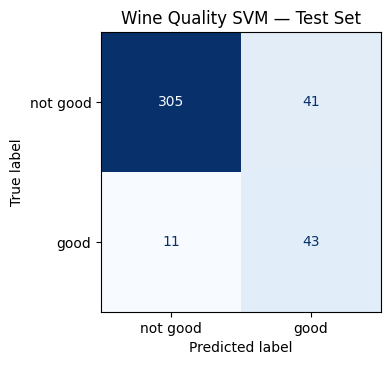

In [ ]:
"""
SVM classification on the UCI Red Wine Quality dataset.

Pipeline:
  1. Load & clean CSV (header has malformed quote characters)
  2. Reframe quality (3-8) as binary: "good" (>=7) vs "not good" (<7)
  3. Stratified train/test split
  4. Pipeline: StandardScaler -> SVC
  5. GridSearchCV over C, kernel, gamma (5-fold stratified CV)
  6. Evaluate on test set
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import os
# 1. Load & clean CSV 
RAW_PATH = os.path.expanduser('~/Downloads/winequality-red-1.csv')
CLEAN_PATH = os.path.expanduser('~/Downloads/wine_clean.csv')

with open(RAW_PATH) as f:
    lines = f.readlines()
lines[0] = lines[0].replace('"', '')          # strip nested quotes from header
with open(CLEAN_PATH, 'w') as f:
    f.writelines(lines)

df = pd.read_csv(CLEAN_PATH, sep=';')

df = pd.read_csv(CLEAN_PATH, sep=';')
print(f"Loaded {df.shape[0]} samples, {df.shape[1]-1} features")
print("Quality distribution:\n", df['quality'].value_counts().sort_index().to_string())

# Reframe target 
# Binary: "good" wine = quality >= 7, "not good" = quality < 7
# Classes 3 and 8 are too rare (10 and 18 samples) for stable multi-class SVM.
X = df.drop(columns='quality').values
y = (df['quality'] >= 7).astype(int).values
print(f"\nBinary target: {y.sum()} good / {(y==0).sum()} not good "
      f"({y.mean()*100:.1f}% positive)")

#  3. Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4 & 5. Pipeline + GridSearchCV 
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced'))   # balanced handles imbalance
])

param_grid = {
    'svc__C':      [0.1, 1, 5, 10, 20, 50, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma':  ['scale', 0.1, 1],
}

# f1 is a better metric than accuracy when classes are imbalanced
grid = GridSearchCV(pipeline, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest params :", grid.best_params_)
print(f"Best CV F1  : {grid.best_score_:.3f}")

#  6. Evaluate on test set 
y_pred = grid.predict(X_test)
print(f"\nTest accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['not good', 'good']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Save confusion matrix figure
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['not good', 'good']).plot(
    ax=ax, cmap='Blues', colorbar=False)
plt.title('Wine Quality SVM — Test Set')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/Downloads/confusion_matrix.png'), dpi=120)
print("\nSaved confusion matrix to confusion_matrix.png")

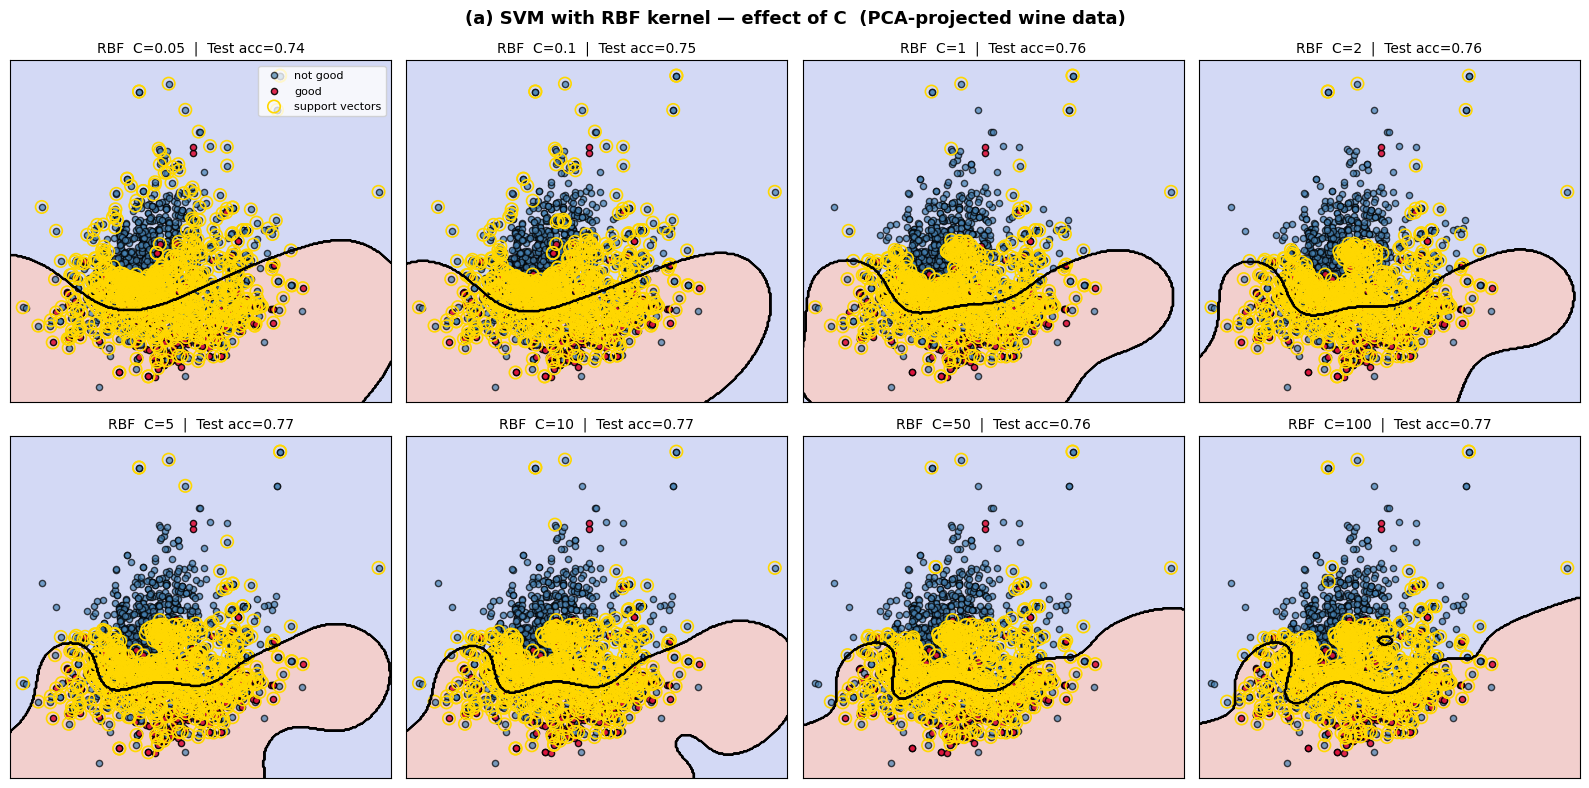


Kernel comparison (C=5, on 2D PCA projection):
  kernel=linear    test accuracy=0.7300
  kernel=poly      test accuracy=0.8425
  kernel=rbf       test accuracy=0.7725
  kernel=sigmoid   test accuracy=0.6100


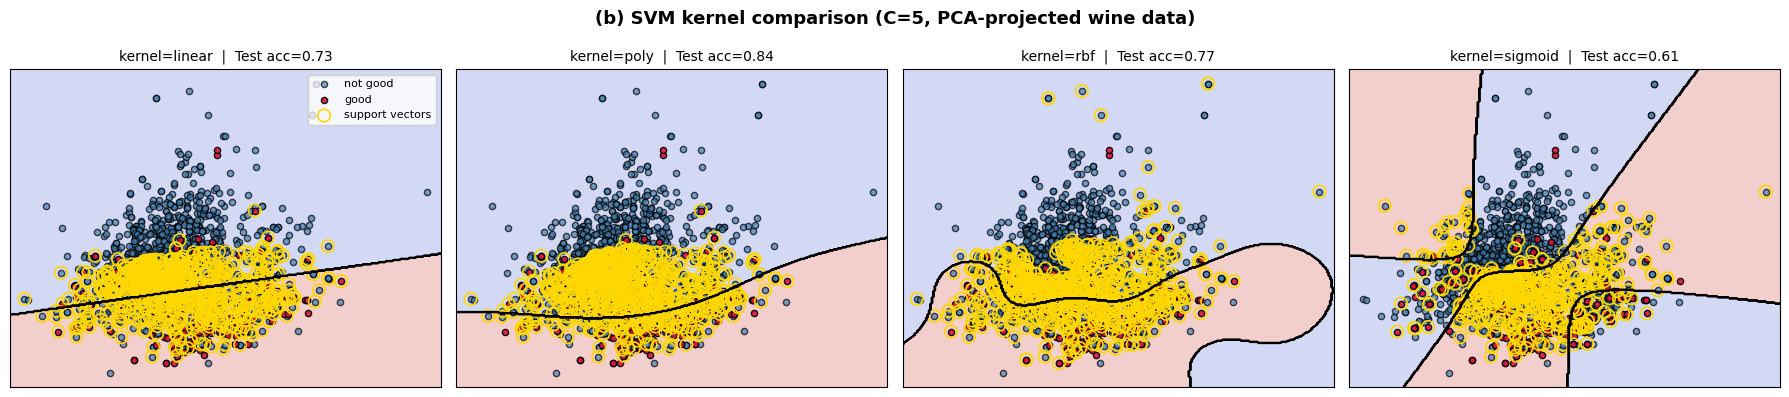

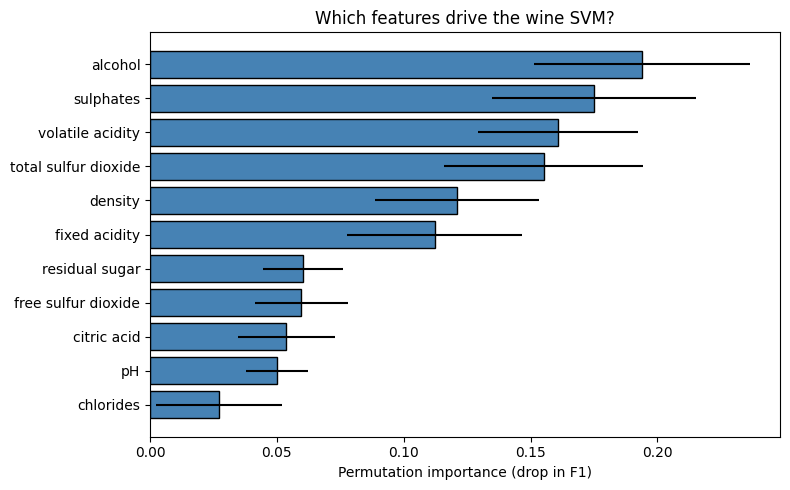

In [ ]:
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

#  7. Visualize SVM decision boundaries 
# The wine data has 11 features, so we need a 2D projection to visualize.
# We'll use PCA (captures most variance in 2D).

feature_names = df.drop(columns='quality').columns.tolist()

def plot_decision_boundary(model, X2d, y, title, ax):
    """Plot decision boundary for a 2D-feature model."""
    x_min, x_max = X2d[:, 0].min() - 0.5, X2d[:, 0].max() + 0.5
    y_min, y_max = X2d[:, 1].min() - 0.5, X2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=1)
    ax.scatter(X2d[y == 0, 0], X2d[y == 0, 1], c='steelblue',
               edgecolor='k', s=20, label='not good', alpha=0.7)
    ax.scatter(X2d[y == 1, 0], X2d[y == 1, 1], c='crimson',
               edgecolor='k', s=20, label='good', alpha=0.9)
    # circle support vectors
    svc = model.named_steps['svc']
    sv_idx = svc.support_
    # support vectors are in scaled space; map back via the pipeline
    sv_2d = X2d[sv_idx] if len(sv_idx) <= len(X2d) else X2d
    ax.scatter(sv_2d[:, 0], sv_2d[:, 1], s=80,
               facecolors='none', edgecolors='gold', linewidths=1.2,
               label='support vectors')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# Project all data into 2D with PCA (fit on training data only)
pca = PCA(n_components=2).fit(StandardScaler().fit_transform(X_train))
X_train_2d = pca.transform(StandardScaler().fit(X_train).transform(X_train))
X_test_2d  = pca.transform(StandardScaler().fit(X_train).transform(X_test))
X_all_2d   = np.vstack([X_train_2d, X_test_2d])
y_all      = np.concatenate([y_train, y_test])

# (a) Effect of C with RBF kernel (8 panels)
C_values = [0.05, 0.1, 1, 2, 5, 10, 50, 100]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, C in zip(axes.ravel(), C_values):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svc', SVC(kernel='rbf', C=C, class_weight='balanced'))])
    pipe.fit(X_train_2d, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test_2d))
    plot_decision_boundary(pipe, X_all_2d, y_all,
                           f'RBF  C={C}  |  Test acc={acc:.2f}', ax)
axes[0, 0].legend(loc='upper right', fontsize=8)
plt.suptitle('(a) SVM with RBF kernel — effect of C  (PCA-projected wine data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/Downloads/svm_C_sweep.png'), dpi=120)
plt.show()

# (b) Kernel comparison at C=5
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
print("\nKernel comparison (C=5, on 2D PCA projection):")
for ax, kernel in zip(axes, kernels):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svc', SVC(kernel=kernel, C=5, class_weight='balanced'))])
    pipe.fit(X_train_2d, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test_2d))
    print(f"  kernel={kernel:<8}  test accuracy={acc:.4f}")
    plot_decision_boundary(pipe, X_all_2d, y_all,
                           f'kernel={kernel}  |  Test acc={acc:.2f}', ax)
axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('(b) SVM kernel comparison (C=5, PCA-projected wine data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/Downloads/svm_kernel_compare.png'), dpi=120)
plt.show()

# (c) Permutation importance — which features the FULL 11-D model actually uses
result = permutation_importance(grid.best_estimator_, X_test, y_test,
                                n_repeats=10, random_state=42, scoring='f1')
order = result.importances_mean.argsort()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.array(feature_names)[order], result.importances_mean[order],
        xerr=result.importances_std[order], color='steelblue', edgecolor='k')
ax.set_xlabel('Permutation importance (drop in F1)')
ax.set_title('Which features drive the wine SVM?')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/Downloads/svm_feature_importance.png'), dpi=120)
plt.show()

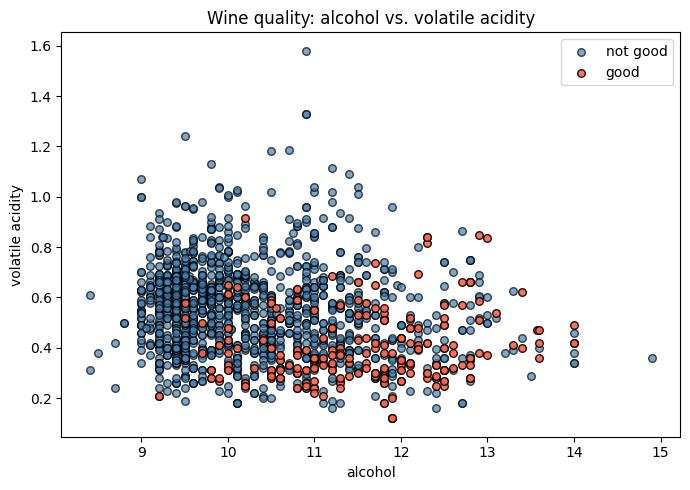

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, feature_names.index('alcohol')],
            X[y == 0, feature_names.index('volatile acidity')],
            color='steelblue', edgecolors='k', s=30, label='not good', alpha=0.7)
plt.scatter(X[y == 1, feature_names.index('alcohol')],
            X[y == 1, feature_names.index('volatile acidity')],
            color='tomato', edgecolors='k', s=30, label='good', alpha=0.9)
plt.xlabel('alcohol')
plt.ylabel('volatile acidity')
plt.title('Wine quality: alcohol vs. volatile acidity')
plt.legend()
plt.tight_layout()
plt.show()